# 🩺 Pneumonia Detection using Deep Learning

# 📌 Introduction

This project focuses on detecting Pneumonia from Chest X-ray images using Deep Learning techniques.

Initially, a baseline CNN model was developed for image classification. Due to overfitting and limited generalization performance, Transfer Learning using MobileNetV2 was later implemented to improve accuracy and feature extraction capability.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense ,Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

# 📂 Dataset Loading

The Chest X-ray dataset containing Pneumonia and Normal images was loaded and organized into:
- Training dataset
- Validation dataset
- Testing dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
base_path = "/content/drive/MyDrive/chest_x-ray"

In [5]:
import os

print(os.listdir(base_path))
print(os.listdir(base_path + "/train"))

['val', 'train', 'test']
['PNEUMONIA', 'NORMAL']


# ⚙️ Data Preprocessing

Data preprocessing techniques were applied before training the model:
- Image resizing
- Pixel normalization
- Batch generation
- Data augmentation

In [6]:
train_data = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 40,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    horizontal_flip = True,
    fill_mode = "nearest"
).flow_from_directory(
    base_path + "/train",
    target_size = (224,224),
    batch_size = 64,
    class_mode = "binary"
)

test_data = ImageDataGenerator(
    rescale = 1./255
).flow_from_directory(
    base_path + "/test",
    target_size = (224,224),
    batch_size = 64,
    class_mode = "binary",
    shuffle = False
)

val_data  = ImageDataGenerator(
    rescale = 1./255
).flow_from_directory(
    base_path + "/val",
    target_size = (224,224),
    batch_size = 64,
    class_mode = "binary"
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


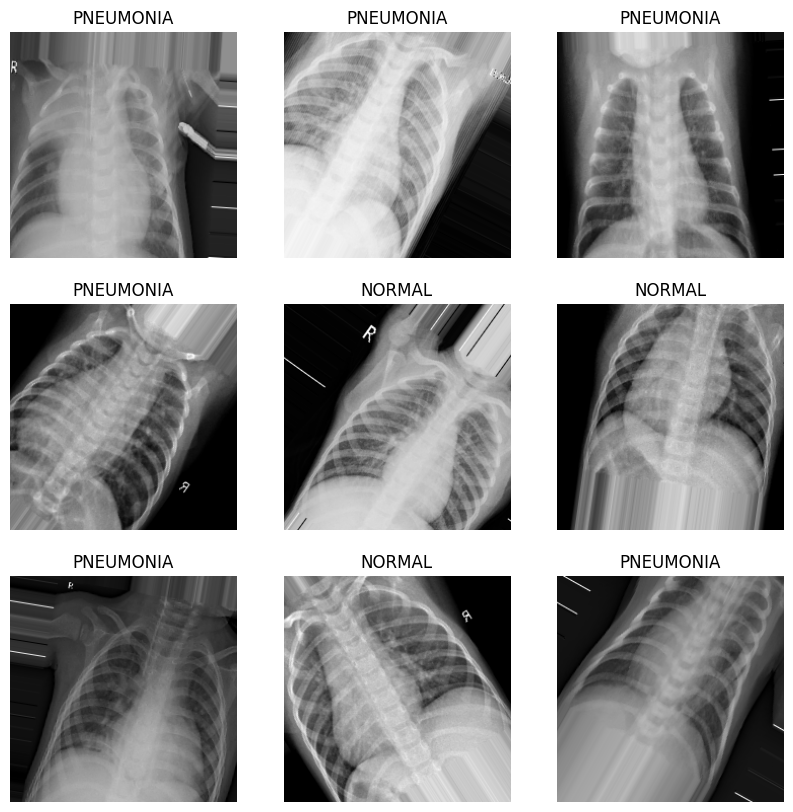

In [7]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title('PNEUMONIA' if labels[i] == 1 else 'NORMAL')
    plt.axis('off')

plt.show()

# 🧠 Baseline CNN Model

Initially, a baseline CNN model was developed for chest X-ray classification.

In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2
)

history = model.fit(
    train_data,
    validation_data = val_data,
    epochs = 8,
    callbacks = [early_stop]
)

Epoch 1/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 2876s 35s/step - accuracy: 0.7983 - loss: 0.4687 - val_accuracy: 0.8125 - val_loss: 0.5597
Epoch 2/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8436 - loss: 0.3322 - val_accuracy: 0.8125 - val_loss: 0.6179
Epoch 3/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8677 - loss: 0.2963 - val_accuracy: 0.8750 - val_loss: 0.4516
Epoch 4/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.8809 - loss: 0.2736 - val_accuracy: 0.8750 - val_loss: 0.4743
Epoch 5/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8911 - loss: 0.2553 - val_accuracy: 0.7500 - val_loss: 0.4738


# 📊 Training Results

The CNN model achieved good training accuracy during training. However, validation performance fluctuated across epochs.

# ⚠️ Problems Observed

Problems identified in the baseline CNN model:
- Overfitting during training
- Unstable validation accuracy
- Poor generalization on unseen chest X-ray images
- Limited feature extraction capability

# 🚀 Why Transfer Learning?

To improve feature extraction and model generalization, Transfer Learning was adopted.

Pretrained models can capture complex image features learned from large-scale datasets, making them more effective for medical image classification tasks compared to training a CNN from scratch.

**MobileNetV2** pretrained on ImageNet was used as the base model for Transfer Learning.

Additional custom classification layers were added on top of the pretrained network for pneumonia detection.

Benefits of using MobileNetV2:
- Better feature extraction
- Reduced overfitting
- Faster convergence
- Improved validation performance

In [13]:
# Load pretrained MobileNetV2 model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build model
model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])


# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [14]:
# Train model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.7276 - loss: 0.5957 - val_accuracy: 0.8750 - val_loss: 0.3763
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8330 - loss: 0.4131 - val_accuracy: 0.8750 - val_loss: 0.3440
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8656 - loss: 0.3378 - val_accuracy: 0.8750 - val_loss: 0.3158
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8808 - loss: 0.3078 - val_accuracy: 0.9375 - val_loss: 0.2742
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8992 - loss: 0.2661 - val_accuracy: 0.9375 - val_loss: 0.2963
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9153 - loss: 0.2515 - val_accuracy: 0.9375 - val_loss: 0.2918


# 🔧 MobileNetV2 Fine-Tuning

Fine-tuning was performed by unfreezing the top layers of MobileNetV2 and retraining the model with a lower learning rate to improve feature learning and validation performance.

In [15]:
base_model.trainable = True

# Freeze first 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
fine_tune_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [18]:
fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[fine_tune_early_stop]
)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.8399 - loss: 0.4009 - val_accuracy: 0.8750 - val_loss: 0.2446
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.8658 - loss: 0.3472 - val_accuracy: 0.8125 - val_loss: 0.3013
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8888 - loss: 0.2969 - val_accuracy: 0.7500 - val_loss: 0.4939
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9036 - loss: 0.2710 - val_accuracy: 0.6875 - val_loss: 0.6232


In [19]:
test_loss, test_acc = model.evaluate(test_data)
print(f'Fine-Tuned Test Accuracy: {test_acc*100:.2f}%')
print(f'Fine-Tuned Test Loss: {test_loss:.4f}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 362s 40s/step - accuracy: 0.8718 - loss: 0.2766
Fine-Tuned Test Accuracy: 87.18%
Fine-Tuned Test Loss: 0.2766


# 📊 Detailed Model Evaluation

In medical image classification tasks such as pneumonia detection, evaluation metrics beyond accuracy are important.

Particularly, **Recall (Sensitivity)** is critical because it measures how effectively the model identifies actual pneumonia cases.

A high recall value reduces False Negatives, ensuring fewer pneumonia patients are missed during prediction.

In [20]:
# Reset generator
test_data.reset()

# Predict entire test set
predictions = model.predict(test_data, verbose=1)

# Convert probabilities to labels
pred_labels = (predictions > 0.5).astype(int)

# True labels
true_labels = test_data.classes

# Results
print(confusion_matrix(true_labels, pred_labels))
print(classification_report(true_labels, pred_labels))

10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
[[170  64]
 [ 16 374]]
              precision    recall  f1-score   support

           0       0.91      0.73      0.81       234
           1       0.85      0.96      0.90       390

    accuracy                           0.87       624
   macro avg       0.88      0.84      0.86       624
weighted avg       0.88      0.87      0.87       624



# 💾 Saving Fine-Tuned Model

In [21]:

model.save("fine_tuned_mobilenetv2.keras")

print("Fine-tuned MobileNetV2 model saved successfully.")

Fine-tuned MobileNetV2 model saved successfully.


# 🔍 Inference on Unseen Chest X-ray Image

The fine-tuned MobileNetV2 model was tested on a new unseen chest X-ray image to evaluate real-world prediction capability.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Prediction: Pneumonia
Prediction Score: 0.98632514


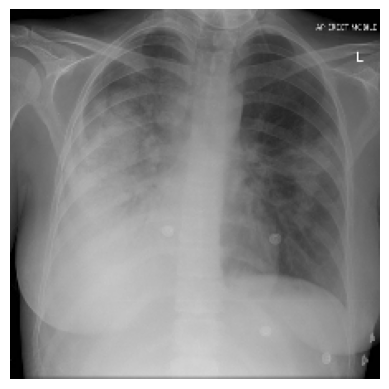

In [26]:
from tensorflow.keras.preprocessing import image
# Path to unseen image
img_path = "/content/drive/MyDrive/Inference x-ray/test_image.png"   # change image path

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Display image
plt.imshow(img)
plt.axis('off')

# Convert image to array
img_array = image.img_to_array(img)

# Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# Normalize image
img_array = img_array / 255.0

# Prediction
prediction = model.predict(img_array)

# Prediction result
if prediction[0][0] > 0.5:
    print("Prediction: Pneumonia")
else:
    print("Prediction: Normal")

# Prediction score
print("Prediction Score:", prediction[0][0])

# ✅ Final Conclusion

This project explored deep learning approaches for pneumonia detection using chest X-ray images.

Initially, a baseline CNN model was developed, but it showed overfitting and poor generalization on unseen data. To overcome these limitations, Transfer Learning using MobileNetV2 was implemented and fine-tuned.

The fine-tuned MobileNetV2 model demonstrated:
- Improved feature extraction
- Better validation performance
- Reduced overfitting
- Better generalization on unseen chest X-ray images

Finally, the trained model was tested on unseen images for real-world inference, demonstrating the practical applicability of deep learning in medical image classification tasks.